In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import torchvision.transforms as T
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import torch.nn as F

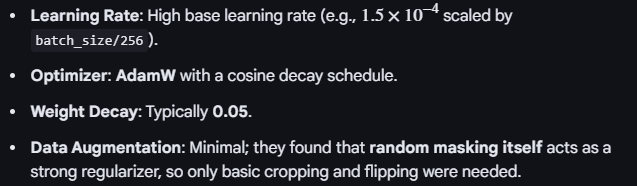

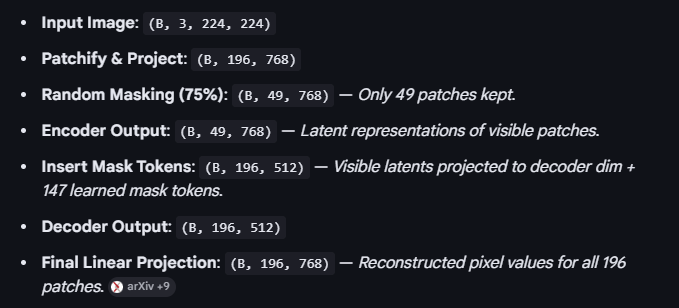

In [ ]:
transform = T.Compose([
    T.Resize(224),  # ViT patch size
    T.Grayscale(num_output_channels=3),  # Convert to RGB
    T.ToTensor(),
    T.Normalize([0.5], [0.5])
])

train_ds = MNIST('data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_ds, 256, shuffle=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 58.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.71MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.87MB/s]


In [ ]:
for image,label in train_loader:
  break

In [ ]:
image[0].shape

torch.Size([3, 224, 224])

In [ ]:
class patchEmbedding(nn.Module):
  def __init__(self,patch_size,in_channels,embed_dim):
    super().__init__()
    self.proj = nn.Conv2d(
        in_channels = in_channels,
        out_channels = embed_dim,
        stride = patch_size,
        kernel_size = patch_size
    )
  def forward(self,x):
    ## assuming the shape of x = (batch size,channels,height,width)
    x = self.proj(x) # (batch_size,768,14,14)
    #print("proj",x.shape)
    x = x.flatten(2,-1) # (batch,768,196)
    #print("flatten",x.shape)
    x = x.transpose(1,2) # (batch_size,196,768)
    #print("transpose",x.shape)
    return x

In [ ]:
class PositionalEncoding(nn.Module):
  def __init__(self,patches,embed_dim):
    super().__init__()
    ## img = (3,224,224) => (batch_size,patches,embed_dim)
    self.d_k = embed_dim
    self.patches = patches
    pe = torch.zeros(patches,self.d_k) # (197,768)
    div = torch.exp(torch.arange(0,self.d_k,2).float() * -(math.log(1000.0)/self.d_k)) # (1,384)
    ### range(0,df-2,2) => 2i
    ### -(math.log(1000.0)/self.d_k) => -log(1000.0)/d_k
    ### multiplication => (2i/d_k) * -log(100.000)
    ### exp = -1000.0^(2i/d_k) => 1/1000.o^(2i/dk)
    position = torch.arange(0,patches).float().unsqueeze(1) # (197,1)
    #print("before position")
    pe[:,0::2] = torch.sin(position*div) # only even positions are taken (197,1)*(1,384) = (197,384)
    pe[:,1::2] = torch.cos(position*div) # only the odd positions are taken(197,384)
    # (batch,197,384)
    #print("pe done ")
    pe = pe.unsqueeze(0) # adding the batch parameter
    self.register_buffer("pe",pe) # setting in the buffer to avoid the backtracking
  def forward(self,x):
    return x + (self.pe[:,:self.patches,:]).requires_grad_(False) # adding the positional vector => :self.patches are added to avoid the upscale in that dim

In [ ]:
## global linear attention
class MultiHeadAttention(nn.Module):
  def __init__(self,seq_len,embedding_dim,heads,head_dim,num_chunks,chunk_size):
    super().__init__()
    assert seq_len == math.floor(seq_len / chunk_size) *chunk_size
    assert embedding_dim == heads * head_dim
    self.heads = heads
    self.head_dim = head_dim
    self.chunk_size = chunk_size
    self.num_chunks = math.ceil(seq_len / chunk_size)
    self.Q = nn.Linear(embedding_dim,embedding_dim)
    self.K = nn.Linear(embedding_dim,embedding_dim)
    self.V = nn.Linear(embedding_dim,embedding_dim)

  def feature_map(self,x):
    return torch.clamp(F.elu(x) + 1,min=0.0,max=5.0)

  def forward(self,x):
    # x = (32,100,128)
    B,L,E =  x.shape
    #print(type(L))
    q = self.feature_map(self.Q(x)).view(B,L, self.heads, self.head_dim).transpose(1, 2) # (32,100,128) => (32,100,2,64) => (32,2,100,64)
    k = self.feature_map(self.K(x)).view(B,L, self.heads, self.head_dim).transpose(1, 2)
    v = self.feature_map(self.V(x)).view(B,L, self.heads, self.head_dim).transpose(1, 2)
    # 2. Compute Global KV State (The associative trick)
    # Instead of chunks, we aggregate the entire image context at once.
    # kv shape: (B, heads, head_dim, head_dim)
    kv = torch.matmul(k.transpose(-1, -2), v)

    # 3. Compute Normalization factor (Denominator)
    # z shape: (B, heads, head_dim, 1)
    z = k.sum(dim=2, keepdim=True).transpose(-1, -2)

    # 4. Global Attention Output
    # num: (B, heads, L, head_dim)
    num = torch.matmul(q, kv)
    # den: (B, heads, L, 1)
    den = torch.matmul(q, z) + 1e-5
    out = num / den
    out = out.transpose(1, 2).reshape(B, L, E)
    return out

In [ ]:
# # chunk wise parallel
# class MultiHeadAttention(nn.Module):
#   def __init__(self,seq_len,embedding_dim,heads,head_dim,num_chunks,chunk_size):
#     super().__init__()
#     #assert seq_len == math.floor(seq_len / chunk_size) *chunk_size
#     assert embedding_dim == heads * head_dim
#     self.heads = heads
#     self.head_dim = head_dim
#     self.chunk_size = chunk_size
#     self.num_chunks = math.ceil(seq_len / chunk_size)
#     self.Q = nn.Linear(embedding_dim,embedding_dim)
#     self.K = nn.Linear(embedding_dim,embedding_dim)
#     self.V = nn.Linear(embedding_dim,embedding_dim)

#   def feature_map(self,x):
#     return torch.clamp(F.elu(x) + 1,min=0.0,max=5.0)

#   def forward(self,x):
#     # x = (32,100,128)
#     B,L,E =  x.shape
#     #print(type(L))
#     q = self.feature_map(self.Q(x)).view(B,L, self.heads, self.head_dim).transpose(1, 2) # (32,100,128) => (32,100,2,64) => (32,2,100,64)
#     k = self.feature_map(self.K(x)).view(B,L, self.heads, self.head_dim).transpose(1, 2)
#     v = self.feature_map(self.V(x)).view(B,L, self.heads, self.head_dim).transpose(1, 2)
#     ## chunk wise parallel
#     S_ = []
#     Z_ = []
#     S =  torch.zeros(B, self.heads, self.head_dim, self.head_dim, device=x.device) # (32,2,64,64)
#     Z = torch.zeros(B, self.heads, self.head_dim, 1, device=x.device) # (32,2,64,1)
#     for c in range(self.num_chunks):
#       ## creating the chunks
#       st,ed = (c*self.chunk_size),min((c+1)*self.chunk_size,L)
#       k_i = k[:, :, st:ed, :] # (32,2,10,64)
#       v_i = v[:, :, st:ed, :] # (32,2,10,64)
#       #print(k_i.shape,v_i.shape,v_i.transpose(3,2).shape)
#       kv = torch.matmul(k_i.transpose(-2,-1),v_i)
#       #print(kv.shape)
#       S = S + kv # (32,2,64,64)
#       #print(Z.shape,k_i.transpose(-1,-2).shape,k_i.transpose(-1,-2).sum(dim=3,keepdim=True).shape)
#       Z = Z + k_i.sum(dim=2).unsqueeze(-1)  # (32,2,64,1) here the embed_dim is add to one and get the scaling at each embed_dim
#       #print(Z.shape,k_i.sum(dim=2).unsqueeze(-1).shape)
#       #break
#       S_.append(S.clone())
#       Z_.append(Z.clone())

#     O = torch.zeros_like(v)
#     for c in range(self.num_chunks):
#       st,ed = (c*self.chunk_size),min((c+1)*self.chunk_size,L)
#       prev_S = S_[c-1] if c > 0 else torch.zeros_like(S)
#       prev_Z = Z_[c-1] if c > 0 else torch.zeros_like(Z)
#       q_i = q[:, :, st:ed, :]
#       num = torch.matmul(q_i,prev_S)
#       den = torch.matmul(q_i,prev_Z) + 1e-4
#       O[:, :, st:ed, :] = num/den
#     return O.transpose(1, 2).reshape(B, L, E)

In [ ]:
class LayerNorm(nn.Module):
  def __init__(self):
    super().__init__()
    self.eps = 0.01
    self.alpha = nn.Parameter(torch.ones(1))
    self.beta = nn.Parameter(torch.ones(1))
    pass
  def forward(self,x):
    mean = x.mean(dim=-1,keepdim=True)
    std = x.std(dim=-1,keepdim=True)
    return (self.alpha * ((x - mean)/(std+self.eps))) + self.beta

In [ ]:
class FeedForwardlayer(nn.Module):
  def __init__(self,patches,embed_dim):
    super().__init__()
    self.dim = 2048
    self.fc_1 = nn.Linear(embed_dim,self.dim)
    self.fc_2 = nn.Linear(self.dim,embed_dim)
    self.gelu = F.gelu()
  def forward(self,x):
    return self.fc_2(self.gelu(self.fc_1(x)))

In [ ]:
class ResidualBlock(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm = LayerNorm()
  def forward(self,X,sublayer):
    #print("in residual ")
    return X + sublayer(self.layer_norm(X)) # ada and norm
    ## here the sublayer is normed first then add

In [ ]:
class EncoderBlock(nn.Module):
  def __init__(self,attention:MultiHeadAttention,fnn:FeedForwardlayer,patches,embed_dim):
    super().__init__()
    self.attention = attention
    self.fnn = fnn
    self.patches = patches
    self.embed_dim = embed_dim
    self.residual = nn.ModuleList([ResidualBlock() for _ in range(2)]) # we want and 2 residual layer connected
  def forward(self,X):
    X = self.residual[0](X,lambda x:self.attention(X)) ## here the attention is second layer (sublayer) and the X is the input which is going to add
    X = self.residual[1](X,lambda x:self.fnn(X))
    return X

In [ ]:
class DecoderBlock(nn.Module):
  def __init__(self,attention:MultiHeadAttention,fnn:FeedForwardlayer,patches,embed_dim,low_dim):
    super().__init__()
    self.attention = attention
    self.fnn = fnn
    self.patches = patches
    self.embed_dim = embed_dim
    self.residual = nn.ModuleList([ResidualBlock() for _ in range(2)]) # we want and 2 residual layer connected
    #self.low_dim_layer = nn.Linear(embed_dim,low_dim)
  def forward(self,X):
    #X = self.low_dim_layer(X) # as the decoder is light weigth so only taking small dim value
    X = self.residual[0](X,lambda x:self.attention(X)) ## here the attention is second layer (sublayer) and the X is the input which is going to add
    X = self.residual[1](X,lambda x:self.fnn(X))
    return X

In [ ]:
## flow till now
# image -> patch embedding -> positional embedding -> masking -> encoder ->  linear projection (setting to deocder dim) -> inverse masking -> positional embedding -> decoder -> decoder head (which predict the image pixel by pisel)

In [ ]:
class DecoderHead(nn.Module):
  def __init__(self,embed_dim,channels,patch_size,decoder_dim):
    super().__init__()
    assert embed_dim == channels * patch_size * patch_size
    num_pixels = embed_dim
    self.layer = nn.Linear(decoder_dim,embed_dim)

  def forward(self,X):
    return self.layer(X)


NameError: name 'nn' is not defined

In [ ]:
class LinearProbing(nn.Module):
  def __init__(self):
    super().__init__()


In [ ]:
class SamplingHead(nn.Module):
  def __init__(self,batch,seq_len,mask_ratio):
    super().__init__()
    self.mask_ratio = mask_ratio
    self.uniform = torch.rand(batch,seq_len).to(x.device)
    self.len = int(seq_len*(1-mask_ratio))

  def forward(self,x):
    # x = (b,seq_len,embed) = (32,196,768)
    B,N,D = x.size()
    ids_shuffle = torch.argsort(self.uniform,dim=1) # [[[0.4,0.3,0.5]]] -> argsort -> [[[0,1,2]]] -> dim=1 -> [[1,0,2]]
    ids_restore = torch.argsort(ids_shuffle,dim=1) # [[[1,0,2]]] -> argsort , dim=1 -> [[[0,1,2]]] to keep the track which had sorted
    ids_keep = ids_shuffle[:,:self.len] # only the 25% are considering
    x_masked = torch.gather(x,dim=1,index=ids_keep.unsqueeze(-1).repeat(1,1,D))
    mask = torch.ones(B,N)
    mask[:,:self.len] = 0
    mask = torch.gather(mask,dim=1,index=ids_restore)
    return x_masked,mask,ids_restore

In [ ]:
encoder_output = torch.zeros(32,49,768)
masked_patches = 147
masked_tokens = torch.zeros(32,147,768)
tokens = torch.cat([encoder_output,masked_tokens],dim=1) # here the remaning masked patches are concataned at the end then the pathes are correctly taken
x = torch.gather(
    tokens,dim=1,index = ids_restore.unsqueeze(-1).repeat(1,1,768)
)

In [ ]:
class Inverse_samplingHead(nn.Module):
  def __init__(self,masked_patches):
    super().__init__()
    self.masked_patches = masked_patches
  def forward(self,encoder_x,ids_restore):
    B,N,E = encoder_x.size()
    masked_tokens = torch.zeros(B, self.masked_patches, E, device=encoder_x.device, dtype=encoder_x.dtype)
    tokens = torch.cat([encoder_x,masked_tokens],dim=1)
    x =  torch.gather(tokens,dim=1,index = ids_restore.unsqueeze(-1).repeat(1,1,E))
    return x

In [ ]:
class linearProjection(nn.Module):
  def __init__(self,encoder_dim,decoder_dim):
    super().__init__()
    self.encoder_dim = encoder_dim
    self.decoder_dim = decoder_dim
    self.light_weight = nn.Linear(encoder_dim,decoder_dim)
  def forward(self,x):
    b,l,e = x.size()
    x = self.light_weight(x)
    return x

In [ ]:
class PatchImage(nn.Module):
    def __init__(self, height, width, in_channels, patch_size):
        super().__init__()
        self.height = height
        self.width = width
        self.in_channels = in_channels
        self.patch_size = patch_size
        self.num_patches_h = height // patch_size  # 224//16 = 14
        self.num_patches_w = width // patch_size   # 14
        self.num_patches = self.num_patches_h * self.num_patches_w  # 196

    def forward(self, x):
        # x from decoder head: (B, 196, 768) where 768 = patch_size^2 * in_channels = 16*16*3
        B, N, patch_dim = x.size()
        x = x.view(B, self.num_patches_h, self.num_patches_w, patch_dim)
        patch_pixels = patch_dim // self.in_channels  # 768 // 3 = 256
        patch_h = int(patch_pixels ** 0.5)
        x = x.view(B, self.num_patches_h, self.num_patches_w,
                   patch_h, patch_h, self.in_channels)
        x = x.permute(0, 1, 3, 2, 4, 5).contiguous()  # (B,14,16,14,16,3)
        x = x.view(B, self.height, self.width, self.in_channels)
        return x

In [ ]:
class maskedAutoencoder(nn.Module):
  def __init__(encoder:EncoderBlock,decoder:DecoderBlock,output_head:DecoderHead,patch_embedding:PatchEmbedding,positional_embedding:PositionalEmbedding,sampling:SamplingHead,inverse_sampling:Inverse_samplingHead,linear_proj:linearProjection,patch_to_image:PatchImage,encoder_dim,decoder_dim,mask_ratio=0.75):
    super().__init__()
    self.encoder = encoder
    self.decoder = decoder
    self.output_head = output_head
    self.patch_embedding = patch_embedding
    self.positional_embedding = positional_embedding
    self.sampling = sampling
    self.inverse_sampling = inverse_sampling
    self.mask_ratio = mask_ratio
    self.linear_proj = linear_proj
    self.patchToImage = patch_to_image
  def forward(self,x):
    H,W,C = x.size() # (224,224,3) and image in batch
    ### initial part ###
    x = self.patch_embedding(x) # here the image is flatten in the patches = (32,196,768)
    x = self.positional_embedding(x) # here the patches are positionally encoded
    ### masking head ###
    x,mask,ids_restore = self.sampling(x,self.mask_ratio) # here the masking is done
    ### Encoder ###
    x = self.encoder(x) # here and encoder block is trained
    ## x = (32,49,768) -> how dimension
    ### linear projection
    _,_,encoder_dim = x.size()
    assert encoder_dim == self.encoder_dim # just for validation
    x = self.linear_proj(x) # embedding dim taken from 768 -> 512 as it is light weight decoder
    ## inverse masking
    x = self.inverse_sampling(x,ids_restore) # here the orignal image with all patches return but with masked heads
    ## decoder head
    x = self.decoder(x) # (32,196,512)
    ## output head
    x = self.output_head(x) # here pixel by pixel image i done
    ## reshaping to image
    x = self.patchToImage(x)
    return x